# Day 2：Chemical Ontology 与 Physical Constitution

今天把 ChemWorld 当作一个“有宪法的世界”来看：物质、容器、仪器、操作、
反应、单位和安全边界都必须被显式声明并可执行检查。


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(2)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)


project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day02


In [2]:
tu.display_learning_goal(
    2,
    "世界宪法",
    [
        "查看 ontology:操作、仪器、反应和状态变量。",
        "理解 physical constitution checklist。",
        "演示动作前置条件和单位换算。",
        "把 chemical intuition 变成 executable constraints。",
    ],
)


In [3]:
tu.display_api_card()


In [4]:
tu.display_student_checkpoint(
    2,
    [
        'one trajectory table or JSONL artifact',
        'one figure generated from your own run',
        'one chemical hypothesis',
        'one proposed next experiment',
        'one note on how GPT or another assistant was used',
    ],
)


In [5]:
import gymnasium as gym

env = gym.make("BatchReactorWorld", world_split="public-dev", budget=8, seed=42)
env.reset(seed=42)
task_info = env.unwrapped.task_info()
constitution = env.unwrapped.constitution_summary()
env.close()

tu.show_json_panel(
    "Task identity",
    {
        "env_id": task_info["env_id"],
        "world_id": task_info["world_id"],
        "split": task_info["world_split"],
        "family": task_info["world_family_version"],
    },
)


In [6]:
operations = pd.DataFrame(task_info["operations"])
instruments = pd.DataFrame(
    [
        {
            "id": key,
            "name": item["name"],
            "observable_keys": ", ".join(item["observable_keys"]),
            "cost": item["cost"],
            "sample_volume_L": item["sample_volume_L"],
            "requires_terminated": item["requires_terminated"],
        }
        for key, item in task_info["instruments"].items()
    ]
)
display(operations[["id", "required_fields", "preconditions"]])
display(instruments)


,id,required_fields,preconditions
0,add_reagent,[amount_mol],[not_terminated]
1,add_solvent,"[volume_L, solvent]",[not_terminated]
2,add_catalyst,"[catalyst_amount_mol, catalyst]",[not_terminated]
3,heat,"[target_temperature_K, duration_s, stirring_sp...","[has_volume, has_material]"
4,wait,"[duration_s, stirring_speed_rpm]","[has_volume, has_material]"
5,sample,[sample_volume_L],[has_volume]
6,quench,[],[has_volume]
7,terminate,[],[has_material]
8,measure,[instrument],"[has_volume, instrument_specific]"


,id,name,observable_keys,cost,sample_volume_L,requires_terminated
0,hplc,HPLC,"yield, selectivity, byproduct_signal",0.080,2.0000e-04,False
1,gc,GC,"byproduct_signal, degradation_warning",0.060,1.5000e-04,False
2,uvvis,UV-vis,"yield, conversion",0.025,5.0000e-05,False
3,final_assay,Final assay,"yield, selectivity, conversion, byproduct_sign...",0.160,3.0000e-04,True


In [7]:
print("constitution passed:", constitution["passed"])
display(pd.DataFrame(constitution["checks"]).head(16))
print("rules:")
for rule in constitution["rules"]:
    print("-", rule)


constitution passed: True


,name,passed,message,value,tolerance
0,nonnegative:amount:A,True,amount:A=0.0,0.00,5.0000e-07
1,nonnegative:amount:P,True,amount:P=0.0,0.00,5.0000e-07
2,nonnegative:amount:B,True,amount:B=0.0,0.00,5.0000e-07
3,nonnegative:amount:D,True,amount:D=0.0,0.00,5.0000e-07
4,nonnegative:amount:E,True,amount:E=0.0,0.00,5.0000e-07
5,nonnegative:amount:Cat_active,True,amount:Cat_active=0.0,0.00,5.0000e-07
6,nonnegative:amount:Cat_dead,True,amount:Cat_dead=0.0,0.00,5.0000e-07
7,nonnegative:volume_L,True,volume_L=0.0,0.00,5.0000e-07
8,nonnegative:temperature_K,True,temperature_K=298.15,298.15,5.0000e-07
9,nonnegative:pressure_Pa,True,pressure_Pa=101325.0,101325.00,5.0000e-07


rules:
- material_conservation
- nonnegative_state
- unit_consistency
- yield_upper_bound
- energy_balance
- observation_non_omniscient
- measurement_has_cost
- action_preconditions
- safety_constraints
- public_private_reproducibility


In [8]:
from chemworld.foundation.units import convert_value, supported_units

unit_table = pd.DataFrame(
    [
        {
            "unit": unit,
            "dimension": spec.dimension,
            "canonical_unit": spec.canonical_unit,
        }
        for unit, spec in supported_units().items()
    ]
)
display(unit_table)
print("25 degC in K:", convert_value(25.0, "degC", "K"))
print("2.5 h in s:", convert_value(2.5, "h", "s"))
print("125 mL in L:", convert_value(125.0, "mL", "L"))


,unit,dimension,canonical_unit
0,J,energy,J
1,K,temperature,K
2,L,volume,L
3,Pa,pressure,Pa
4,bar,pressure,Pa
5,currency,cost,currency
6,degC,temperature,K
7,dimensionless,dimensionless,dimensionless
8,h,time,s
9,kJ,energy,J


25 degC in K: 298.15
2.5 h in s: 9000.0
125 mL in L: 0.125


In [9]:
bad_events = [
    {'operation': 'measure', 'instrument': 'final_assay'},
    {'operation': 'heat', 'target_temperature_K': 390.0, 'duration_s': 300.0},
]
bad_run = tu.run_events(bad_events, seed=13)
display(
    bad_run[
        [
            'step',
            'operation',
            'instrument',
            'reward',
            'measurement_cost',
            'sample_consumed',
            'precondition_failed',
            'observed_keys',
            'error_message',
        ]
    ]
)
assert bad_run['precondition_failed'].all()
assert bad_run['observed_keys'].eq('').all()
assert bad_run[['yield', 'selectivity', 'conversion', 'score']].isna().all().all()


,step,operation,instrument,reward,measurement_cost,sample_consumed,precondition_failed,observed_keys,error_message
0,1,measure,final_assay,0.0,0.0,0.0,True,,"Action precondition failed: has_volume, measur..."
1,2,heat,None,0.0,0.0,0.0,True,,"Action precondition failed: has_volume, has_ma..."


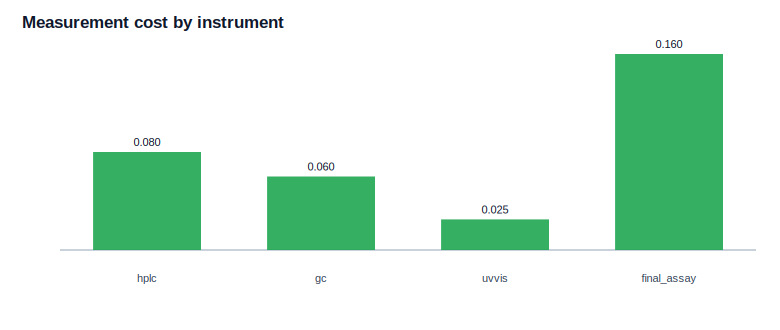

In [10]:
display(
    tu.bar_svg(
        instruments["id"].tolist(),
        instruments["cost"].astype(float).tolist(),
        title="Measurement cost by instrument",
        color="#16a34a",
    )
)


## 当天练习

解释为什么 `final_assay` 需要 `terminate` 之后才能做。再找一个你认为应该被
constitution 检查捕获的错误动作，并尝试构造出来。
